# Car Price Prediction
End-to-end machine learning project: data cleaning, EDA, model comparison, and saving the best model.

**Dataset:** 2,840 used cars with features — brand, year, mileage, and price (USD).

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_theme(style='darkgrid')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load & Inspect Dataset

In [2]:
df = pd.read_csv('dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2840, 6)


,name,year,miles,color,condition,price
0,Kia Forte,2022,"41,406 miles","Gray exterior, Black interior","No accidents reported, 1 Owner","$15,988"
1,Chevrolet Silverado 1500,2021,"15,138 miles","White exterior, Black interior","1 accident reported, 1 Owner","$38,008"
2,Toyota RAV4,2022,"32,879 miles","Silver exterior, Unknown interior","No accidents reported, 1 Owner","$24,988"
3,Honda Civic,2020,"37,190 miles","Blue exterior, Black interior","No accidents reported, 1 Owner","$18,998"
4,Honda Civic,2020,"27,496 miles","Black exterior, Black interior","No accidents reported, 1 Owner","$19,498"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2840 entries, 0 to 2839
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       2840 non-null   object
 1   year       2840 non-null   int64 
 2   miles      2840 non-null   object
 3   color      2840 non-null   object
 4   condition  2840 non-null   object
 5   price      2840 non-null   object
dtypes: int64(1), object(5)
memory usage: 133.3+ KB


In [4]:
df.isnull().sum()

name         0
year         0
miles        0
color        0
condition    0
price        0
dtype: int64

## 3. Data Cleaning
The `miles` and `price` columns are strings with commas and symbols. We need to clean them into numeric values.
We also extract the **brand** from the car name.

In [5]:
# Extract brand from car name
df['brand'] = df['name'].str.split().str[0]

# Clean miles: remove commas and ' miles' text
df['miles_clean'] = pd.to_numeric(
    df['miles'].str.replace(',', '').str.replace(' miles', ''), errors='coerce'
)

# Clean price: remove $ and commas
df['price_clean'] = pd.to_numeric(
    df['price'].str.replace(r'[\$,]', '', regex=True), errors='coerce'
)

# Drop rows with missing values
df = df.dropna(subset=['miles_clean', 'price_clean', 'brand', 'year'])

print(f'Clean dataset: {len(df)} rows, {df["brand"].nunique()} unique brands')
df[['brand', 'year', 'miles_clean', 'price_clean']].head()

Clean dataset: 2840 rows, 42 unique brands


,brand,year,miles_clean,price_clean
0,Kia,2022,41406,15988
1,Chevrolet,2021,15138,38008
2,Toyota,2022,32879,24988
3,Honda,2020,37190,18998
4,Honda,2020,27496,19498


## 4. Exploratory Data Analysis (EDA)

In [6]:
# Basic statistics
df[['year', 'miles_clean', 'price_clean']].describe().round(2)

,year,miles_clean,price_clean
count,2840.00,2840.00,2840.00
mean,2018.83,50138.45,25745.43
std,3.56,36482.44,13627.61
min,2000.00,25.00,4395.00
25%,2017.00,23233.75,17851.00
50%,2020.00,41076.00,23000.00
75%,2021.00,70978.25,31222.50
max,2024.00,307292.00,252900.00


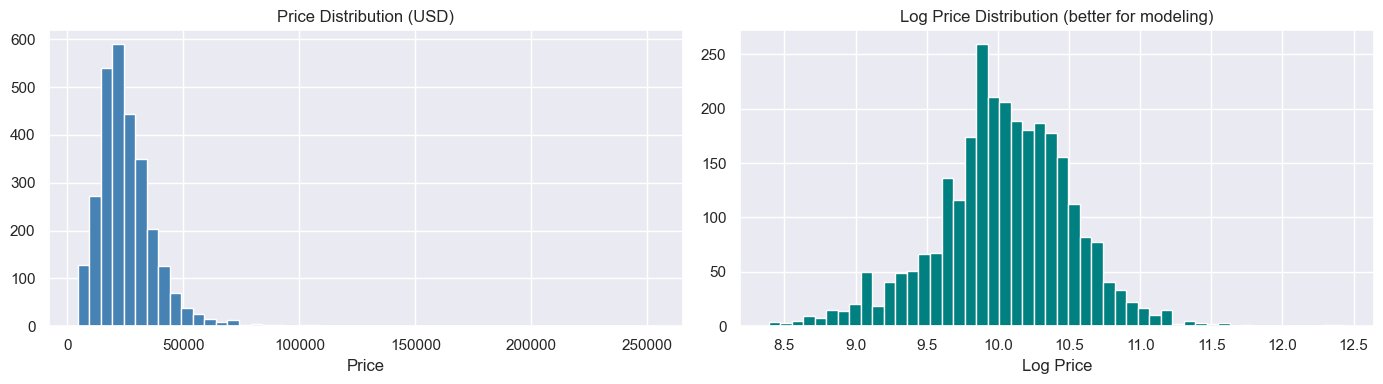

In [7]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price_clean'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (USD)')
axes[0].set_xlabel('Price')

axes[1].hist(np.log(df['price_clean']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Log Price Distribution (better for modeling)')
axes[1].set_xlabel('Log Price')

plt.tight_layout()
plt.show()

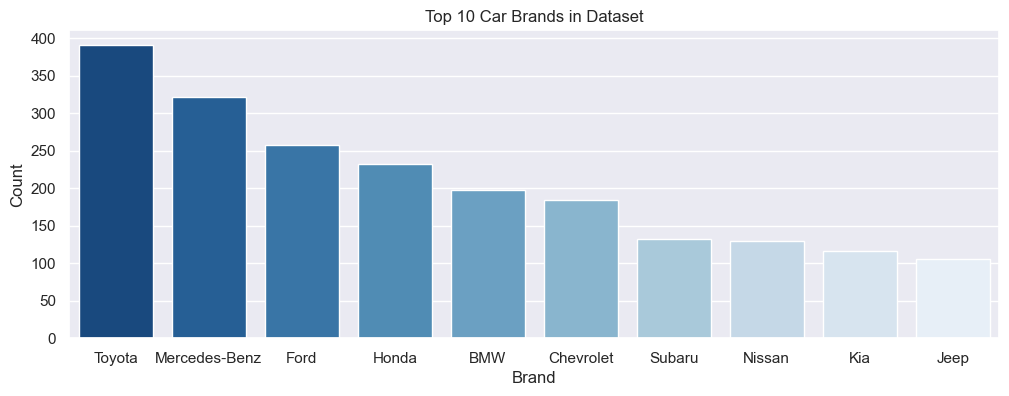

In [8]:
# Top 10 brands by count
top_brands = df['brand'].value_counts().head(10)
plt.figure(figsize=(12, 4))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='Blues_r')
plt.title('Top 10 Car Brands in Dataset')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()

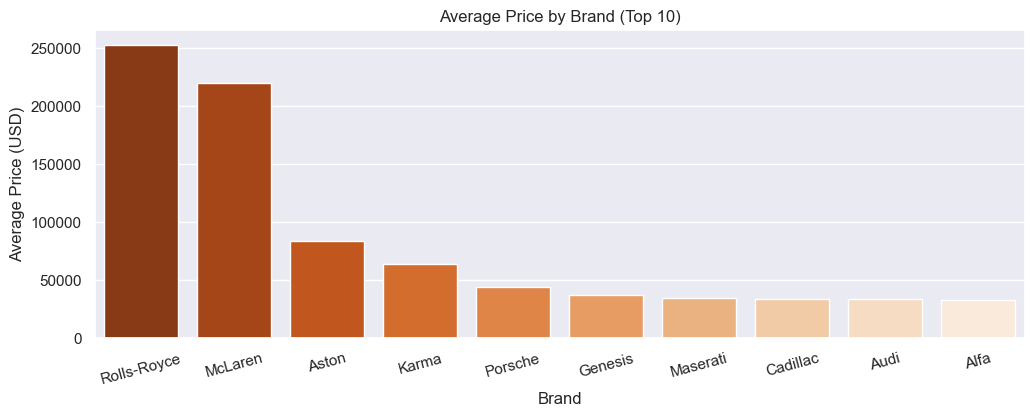

In [9]:
# Average price by brand (top 10)
avg_price = df.groupby('brand')['price_clean'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 4))
sns.barplot(x=avg_price.index, y=avg_price.values, palette='Oranges_r')
plt.title('Average Price by Brand (Top 10)')
plt.xlabel('Brand')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=15)
plt.show()

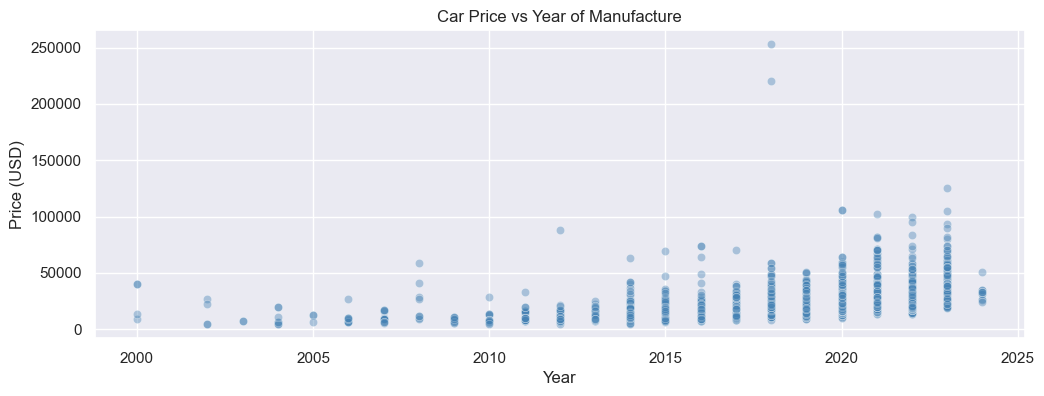

In [10]:
# Price vs Year
plt.figure(figsize=(12, 4))
sns.scatterplot(data=df, x='year', y='price_clean', alpha=0.4, color='steelblue')
plt.title('Car Price vs Year of Manufacture')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.show()

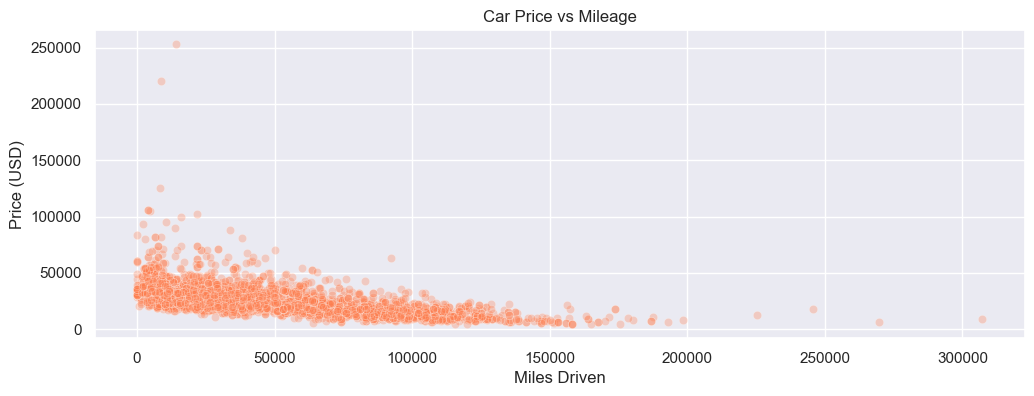

In [11]:
# Price vs Mileage
plt.figure(figsize=(12, 4))
sns.scatterplot(data=df, x='miles_clean', y='price_clean', alpha=0.3, color='coral')
plt.title('Car Price vs Mileage')
plt.xlabel('Miles Driven')
plt.ylabel('Price (USD)')
plt.show()

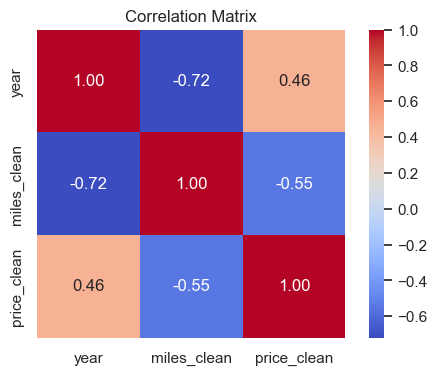

In [12]:
# Correlation heatmap
corr = df[['year', 'miles_clean', 'price_clean']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

## 5. Model Training & Comparison
We compare three regression models:
- **Linear Regression** — simple baseline
- **Random Forest** — ensemble of decision trees
- **Gradient Boosting** — sequential boosting

We apply a **log transform** on price as the target, since price distributions are skewed.

In [13]:
# Features and target
X = df[['brand', 'year', 'miles_clean']]
y = np.log(df['price_clean'])  # log transform

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

Train size: 2272, Test size: 568


In [14]:
# Preprocessor: OneHotEncode brand, pass year and miles as-is
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['brand'])
], remainder='passthrough')

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    r2  = r2_score(y_test, preds)
    mae = mean_absolute_error(np.exp(y_test), np.exp(preds))
    results.append({'Model': name, 'R² Score': round(r2, 3), 'MAE (USD)': int(mae)})
    print(f'{name:25s} → R²: {r2:.3f}  |  MAE: ${mae:,.0f}')

results_df = pd.DataFrame(results)
results_df

Linear Regression         → R²: 0.693  |  MAE: $5,407
Random Forest             → R²: 0.715  |  MAE: $4,955
Gradient Boosting         → R²: 0.699  |  MAE: $5,421


,Model,R² Score,MAE (USD)
0,Linear Regression,0.693,5406
1,Random Forest,0.715,4954
2,Gradient Boosting,0.699,5421


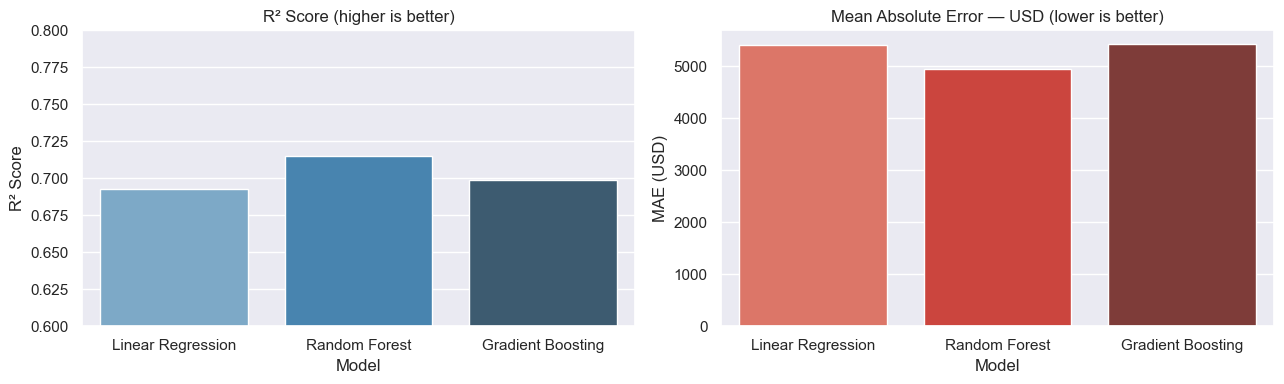

Winner: Random Forest


In [15]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=results_df, x='Model', y='R² Score', palette='Blues_d', ax=axes[0])
axes[0].set_title('R² Score (higher is better)')
axes[0].set_ylim(0.6, 0.8)

sns.barplot(data=results_df, x='Model', y='MAE (USD)', palette='Reds_d', ax=axes[1])
axes[1].set_title('Mean Absolute Error — USD (lower is better)')

plt.tight_layout()
plt.show()
print('Winner: Random Forest')

## 6. Train & Save Best Model
Random Forest gave the best R² and lowest MAE, so we train it on the full dataset and save it.

In [16]:
# Train best model on full dataset
best_pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

best_pipeline.fit(X_train, y_train)

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

# Save brand list and metadata for the Flask app
brands = sorted(df['brand'].unique().tolist())
meta = {
    'brands': brands,
    'year_min': int(df['year'].min()),
    'year_max': int(df['year'].max()),
    'miles_max': int(df['miles_clean'].max())
}
with open('meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print('model.pkl saved!')
print('meta.pkl saved!')

model.pkl saved!
meta.pkl saved!


## 7. Test a Prediction

In [17]:
# Sample prediction
sample = pd.DataFrame([{
    'brand': 'Toyota',
    'year': 2020,
    'miles_clean': 45000 * 0.621371  # km to miles
}])

price_usd = np.exp(best_pipeline.predict(sample)[0])
price_pkr = price_usd * 278

print(f'Car     : Toyota 2020, 45,000 km')
print(f'Price   : ${price_usd:,.0f} USD')
print(f'Price   : PKR {price_pkr:,.0f}')

Car     : Toyota 2020, 45,000 km
Price   : $23,704 USD
Price   : PKR 6,589,811


## ✅ Done!
Model is saved as `model.pkl`. Run `python app.py` to launch the web app.